In [1]:
# Import and setup
import json
import os
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Unsupervised learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

# Domain parsing
import tldextract

# Text analysis
import re
from collections import Counter
from math import log2
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix

stop_words = set(stopwords.words('english'))


In [5]:
'''
recursively load data
'''

data_location = '../data/parked_suspicious/'

with open(f"{data_location}_summary.json") as f:
    summary = json.load(f)

dfs = []

for label in summary.keys():
    clean_label = label.replace(':', '-')
    filename = f"{data_location + clean_label}.jsonl"

    if not os.path.exists(filename):
        print(f"Missing: {filename}")
        continue

    try:
        df = pd.read_json(filename, lines=True)
        dfs.append(df)
        print(f"Loaded {filename} ({len(df)} rows)")
    except ValueError as e:
        print(f"Error reading {filename}: {e}")

combined_df = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(combined_df))
if "service" in combined_df.columns:
    print("Services:")
    print(combined_df["service"].value_counts())

Loaded ../data/parked_suspicious/other-unclassified.jsonl (1000 rows)
Loaded ../data/parked_suspicious/other-empty-title.jsonl (1000 rows)
Loaded ../data/parked_suspicious/default-server.jsonl (1000 rows)
Loaded ../data/parked_suspicious/sedo.jsonl (1000 rows)
Loaded ../data/parked_suspicious/searchhounds.jsonl (1000 rows)
Loaded ../data/parked_suspicious/wix-unconnected.jsonl (1000 rows)
Loaded ../data/parked_suspicious/hugedomains.jsonl (1000 rows)
Loaded ../data/parked_suspicious/godaddy.jsonl (1000 rows)
Loaded ../data/parked_suspicious/afternic.jsonl (1000 rows)
Loaded ../data/parked_suspicious/expired-domain.jsonl (1000 rows)
Loaded ../data/parked_suspicious/atom.jsonl (1000 rows)
Loaded ../data/parked_suspicious/spaceship.jsonl (1000 rows)
Loaded ../data/parked_suspicious/other-domain-as-title.jsonl (642 rows)
Loaded ../data/parked_suspicious/dynadot.jsonl (619 rows)
Loaded ../data/parked_suspicious/brandbucket.jsonl (440 rows)
Loaded ../data/parked_suspicious/default-nginx.json

In [6]:
text_cols = [c for c in ["title", "textSnippet"] if c in combined_df.columns]

url_re = re.compile(r"https?://\S+|www\.\S+", flags=re.I)
domain_re = re.compile(r"\b(?:[a-z0-9-]+\.)+[a-z]{2,}\b", flags=re.I)
number_re = re.compile(r"\b\d+(?:\.\d+)?\b")
non_letter_re = re.compile(r"[^a-z\s]")
whitespace_re = re.compile(r"\s+")

def clean_text(text):
    text = str(text).lower()
    text = url_re.sub(" ", text)
    text = domain_re.sub(" ", text)
    text = number_re.sub(" ", text)
    text = non_letter_re.sub(" ", text)
    text = whitespace_re.sub(" ", text).strip()
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

combined_df["raw_text"] = combined_df[text_cols].fillna("").agg(" ".join, axis=1).str.strip()
combined_df["clean_text"] = combined_df["raw_text"].apply(clean_text)
combined_df["tokens"] = combined_df["clean_text"].str.split()

combined_df["token_count"] = combined_df["tokens"].apply(len)
combined_df["unique_token_count"] = combined_df["tokens"].apply(lambda x: len(set(x)))
combined_df["unique_ratio"] = np.where(
    combined_df["token_count"] > 0,
    combined_df["unique_token_count"] / combined_df["token_count"],
    0
)
combined_df["avg_token_length"] = combined_df["tokens"].apply(
    lambda x: np.mean([len(t) for t in x]) if x else 0
)

display(combined_df[["raw_text", "clean_text", "token_count"]].head(10))


,raw_text,clean_text,token_count
0,Bald verfügbar Bald verfügbar,bald verf gbar bald verf gbar,6
1,Connect Your Domain Connect Your Domain You're...,connect domain connect domain almost done cust...,18
2,A Lola Estilo – Abertura em breve A Lola Estil...,lola estilo abertura em breve lola estilo aber...,34
3,a-petrenko a-petrenko,petrenko petrenko,2
4,Just a moment... Just a moment... p2m-1.forsal...,moment moment verifying human may take seconds...,13
5,Just a moment... Just a moment... p2m-1.forsal...,moment moment verifying human may take seconds...,13
6,Just a moment... Just a moment... p2m-1.forsal...,moment moment verifying human may take seconds...,13
7,A1 Luxuri A1 Luxuri Opening Soon Site and Stor...,luxuri luxuri opening soon site store longer a...,21
8,Something's Wrong Here Something's Wrong Here ...,something wrong something wrong something wron...,16
9,a1pumpingrepair.com | fruits a1pumpingrepair.c...,fruits fruits premium domain sale vs offer ver...,19


In [8]:
token_counts = pd.Series([t for row in combined_df["tokens"] for t in row]).value_counts().head(20)
display(token_counts.to_frame("count"))

,count
domain,16669
sale,9662
page,6169
get,4770
buy,4455
website,4072
name,4033
free,3486
names,3451
available,3110


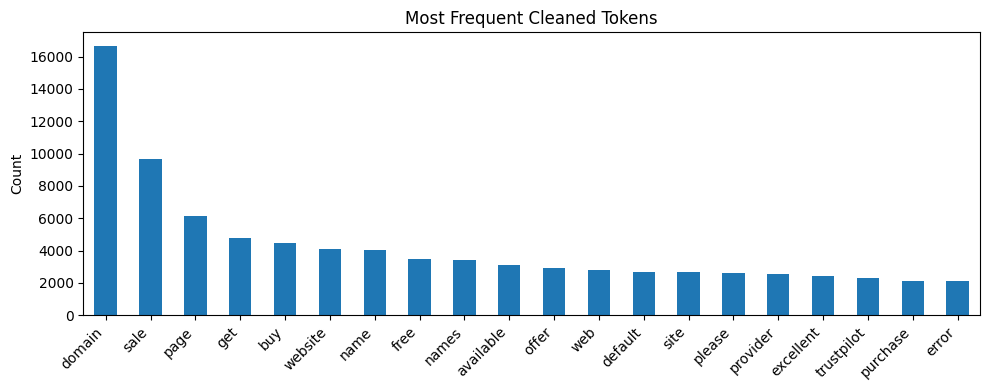

In [9]:
plt.figure(figsize=(10, 4))
token_counts.plot(kind="bar")
plt.title("Most Frequent Cleaned Tokens")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()